In [1]:
import matplotlib.pyplot as plt

from causal_gym.envs.highway import HighwayPCH

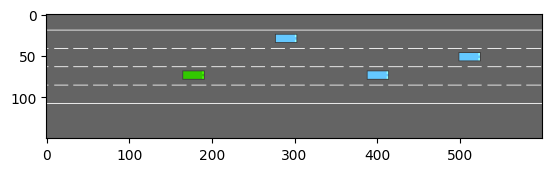

In [2]:
num_steps = 200
pch = HighwayPCH(num_steps=num_steps, render_mode='rgb_array', perception='truth', u_prob=.5)
state, info = pch.reset()
obs = pch.render()
# obs.shape
plt.imshow(obs)

In [3]:
num_steps = 200
pch = HighwayPCH(num_steps=num_steps, render_mode='rgb_array', perception='truth', u_prob=.5)

pch.reset()
frames = []
frames.append(pch.render())
for t in range(num_steps):
    action, obs, reward, terminated, truncated, info = pch.see(show_reward=True)
    frames.append(pch.render())

    if terminated or truncated:
        pch.close()
        break

print([pch.env._meta_actions.ACTIONS_ALL[x] for x in pch.env.X])
print(pch.env.D)
print(pch.env.L)
print(pch.env._I)
print(pch.env.A)
print(pch.env.B)
print(pch.env.W)
print(pch.env._U)
print(pch.env._Y)

['FASTER', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'LANE_LEFT', 'SLOWER']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
[3, np.int64(3), 3, 3, np.int64(3), 3, 3, 3, 3, np.int64(3), 2, np.int64(2)]
[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
[1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1]
[np.float64(29.1455588268693), np.float64(44.0725518550352), np.float64(74.04759978997095), np.float64(104.04333577562184), np.float64(119.04297144067957), np.float64(149.04284691956937), np.float64(164.04283627997302), np.float64(194.04283264360936), np.float64(209.0428323329035), np.float64(238.9965463177245), np.float64(260.3108462234857)]


In [4]:
obs, info = pch.reset()

In [ ]:
# run this cell as many times as you want to see step-by-step data
# run above cell to reset
# run below cell to close properly
action, _, _, _, _, _, = pch.see()
pch.render()
print(pch.env._meta_actions.ACTIONS_ALL[action])
print(pch.env.unwrapped.vehicle.lane_index[2])
print(pch.env.L[-1])
print(pch.env.A[-1])
print(pch.env.B[-1])

In [5]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

In [6]:
display_frames(frames)

Displaying animation.
